In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from category_encoders import CountEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error,
)

In [2]:
from plot_utils import cm_plot, regression_plots

In [3]:
current_dir = os.getcwd()

In [4]:
flights_sampled_parquet = "flights_sampled.parquet"

try:
    df_flights_sampled = pd.read_parquet(os.path.join(current_dir, flights_sampled_parquet))
except FileNotFoundError:
    print(f"Arquivo {flights_sampled_parquet} não encontrado. Certifique-se de rodar o notebook 'us_flights_ml_eda_sampled.ipynb'.")
    raise

In [5]:
df_flights_sampled.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   DESTINATION_STATE        100000 non-null  category
 1   ORIGIN_STATE             100000 non-null  category
 2   MONTH                    100000 non-null  category
 3   DAY                      100000 non-null  category
 4   DAY_OF_WEEK              100000 non-null  category
 5   AIRLINE                  100000 non-null  category
 6   FLIGHT_SEQUENCE          100000 non-null  int64   
 7   ORIGIN_AIRPORT           100000 non-null  category
 8   DESTINATION_AIRPORT      100000 non-null  category
 9   DISTANCE                 100000 non-null  int64   
 10  SCHEDULED_TIME           100000 non-null  int64   
 11  ARRIVAL_DELAY            100000 non-null  int64   
 12  HOUR                     100000 non-null  category
 13  ROUTE                    100000 non-null  category
 14  

In [6]:
df_flights_sampled.dropna(inplace=True)

## Encoding / Scaling

In [7]:
# Colunas categóricas não ordenadas de baixa cardinalidade (One-Hot Encoding)
ohe_cat_cols = ["AIRLINE"]

# Colunas categóricas não ordenadas de alta cardinalidade (Frequency Encoding)
freq_cat_cols = [
    "ORIGIN_AIRPORT", "ORIGIN_CITY", "ORIGIN_STATE",
    "DESTINATION_AIRPORT", "DESTINATION_CITY", "DESTINATION_STATE",
    "ROUTE",
]

# Colunas categóricas ordenadas (Ordinal Encoding + MinMax Scaler)
oe_cat_cols = ["DISTANCE_CATEGORY", "SCHEDULED_TIME_CATEGORY"]

dist_cat_labels = [
    "Short Distance",
    "Medium Distance",
    "Long Distance",
]

sch_time_cat_labels = [
    "Short Duration",
    "Medium Duration",
    "Long Duration",
    "Very Long Duration",
]

# Colunas categóricas ordenadas (MinMax Scaler)
sc_cat_cols = ["MONTH", "DAY", "DAY_OF_WEEK", "HOUR", "FLIGHT_SEQUENCE"]

# Colunas numéricas (MinMax Scaler)
minmax_num_cols = ["DISTANCE", "SCHEDULED_TIME", "DEPARTURE_ACC_MINUTES", "ARRIVAL_ACC_MINUTES"]

# Colunas numéricas (Standard Scaler)
std_num_cols = ["ORIGIN_LATITUDE", "ORIGIN_LONGITUDE", "DESTINATION_LATITUDE", "DESTINATION_LONGITUDE"]

# Colunas booleanas (Passthrough)
bool_cols = ["HOLIDAY_ORIGIN", "HOLIDAY_EVE_ORIGIN", "HOLIDAY_DESTINATION", "HOLIDAY_EVE_DESTINATION"]

preprocessor_standard = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), ohe_cat_cols),
        ("freq", CountEncoder(handle_unknown="value", normalize=True), freq_cat_cols),
        ("ord", Pipeline([
            ("enc", OrdinalEncoder(handle_unknown="error", categories=[dist_cat_labels, sch_time_cat_labels])),
            ("scaler", MinMaxScaler()),
        ]), oe_cat_cols),
        ("ord_minmax_scaler", MinMaxScaler(), sc_cat_cols),
        ("minmax_scaler", MinMaxScaler(), minmax_num_cols),
        ("std_scaler", StandardScaler(), std_num_cols),
    ],
    remainder="passthrough"
)

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cat_cols),
        ("freq", CountEncoder(handle_unknown="value", normalize=True), freq_cat_cols),
        ("ord", OrdinalEncoder(handle_unknown="error", categories=[dist_cat_labels, sch_time_cat_labels]), oe_cat_cols),
    ],
    remainder="passthrough"
)

## Classification

In [8]:
X = df_flights_sampled.drop(columns=["ARRIVAL_DELAY"])

tol_min = 15
y = df_flights_sampled["ARRIVAL_DELAY"] >= tol_min

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
pipelines = {
    "LogisticRegression": Pipeline([
        ("preprocessor", clone(preprocessor_standard)),
        ("classifier", LogisticRegression(solver="liblinear", random_state=42, max_iter=1000)),
    ]),
    "SVM": Pipeline([
        ("preprocessor", clone(preprocessor_standard)),
        ("classifier", LinearSVC(random_state=42, max_iter=2000)),
    ]),
    "DecisionTree": Pipeline([
        ("preprocessor", clone(preprocessor_dt)),
        ("classifier", DecisionTreeClassifier(random_state=42)),
    ]),
}

In [11]:
param_grids = {
    "LogisticRegression": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__l1_ratio": [1, 0],  # l1_ratio = 1 para penalty = "l1", l1_ratio = 0 para penalty = "l2"
        "classifier__class_weight": [None, "balanced"],
    },
    "SVM": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"],
    },
    "DecisionTree": {
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5, 20],
        "classifier__class_weight": [None, "balanced"],
    },
}

GridSearch - LogisticRegression
CV Results:
    classifier__C classifier__class_weight  classifier__l1_ratio  \
0             0.1                      NaN                     1   
1             0.1                      NaN                     0   
2             0.1                 balanced                     1   
3             0.1                 balanced                     0   
4             1.0                      NaN                     1   
5             1.0                      NaN                     0   
6             1.0                 balanced                     1   
7             1.0                 balanced                     0   
8            10.0                      NaN                     1   
9            10.0                      NaN                     0   
10           10.0                 balanced                     1   
11           10.0                 balanced                     0   

    split0_test_score  split1_test_score  split2_test_score  \
0       

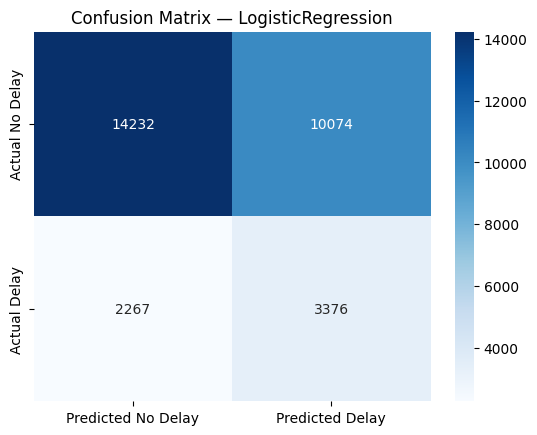

TN: 14232
FP: 10074
FN: 2267
TP: 3376


Metrics:
Accuracy:  0.5879
Precision: 0.2510
Recall:    0.5983
F1-Score:  0.3536


Feature Importance:
                                 feature  importance
19                           freq__ROUTE  108.825462
28         minmax_scaler__SCHEDULED_TIME    3.909158
27               minmax_scaler__DISTANCE    3.530575
17                freq__DESTINATION_CITY    2.833027
15                    freq__ORIGIN_STATE    1.620246
18               freq__DESTINATION_STATE    0.941113
14                     freq__ORIGIN_CITY    0.928069
25               ord_minmax_scaler__HOUR    0.824384
13                  freq__ORIGIN_AIRPORT    0.698801
16             freq__DESTINATION_AIRPORT    0.570712
4                        ohe__AIRLINE_F9    0.546626
30    minmax_scaler__ARRIVAL_ACC_MINUTES    0.545004
7                        ohe__AIRLINE_NK    0.468194
26    ord_minmax_scaler__FLIGHT_SEQUENCE    0.445044
2                        ohe__AIRLINE_DL    0.410656
29  minma

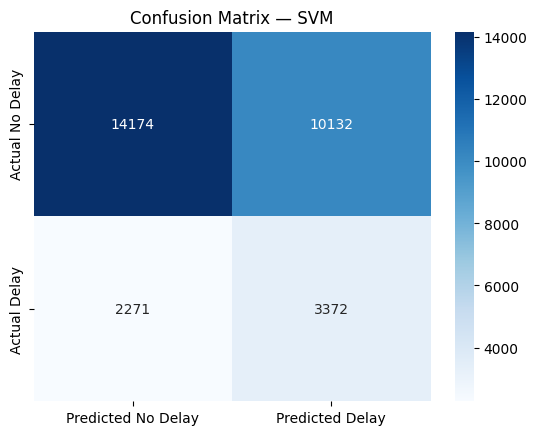

TN: 14174
FP: 10132
FN: 2271
TP: 3372


Metrics:
Accuracy:  0.5859
Precision: 0.2497
Recall:    0.5976
F1-Score:  0.3522


Feature Importance:
                                 feature  importance
28         minmax_scaler__SCHEDULED_TIME    1.486612
17                freq__DESTINATION_CITY    1.367464
27               minmax_scaler__DISTANCE    1.309957
19                           freq__ROUTE    1.106229
15                    freq__ORIGIN_STATE    0.795154
13                  freq__ORIGIN_AIRPORT    0.756203
16             freq__DESTINATION_AIRPORT    0.738831
14                     freq__ORIGIN_CITY    0.557525
18               freq__DESTINATION_STATE    0.484529
25               ord_minmax_scaler__HOUR    0.436790
30    minmax_scaler__ARRIVAL_ACC_MINUTES    0.257336
4                        ohe__AIRLINE_F9    0.254009
7                        ohe__AIRLINE_NK    0.218825
26    ord_minmax_scaler__FLIGHT_SEQUENCE    0.206620
2                        ohe__AIRLINE_DL    0.198967
11       

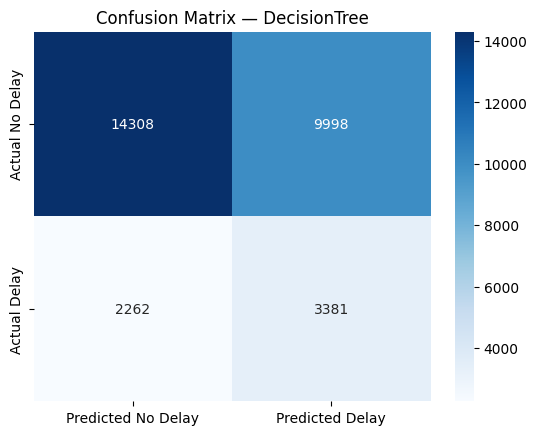

TN: 14308
FP: 9998
FN: 2262
TP: 3381


Metrics:
Accuracy:  0.5906
Precision: 0.2527
Recall:    0.5991
F1-Score:  0.3555


Feature Importance:
                               feature  importance
38    remainder__DEPARTURE_ACC_MINUTES    0.291741
24                      remainder__DAY    0.094211
23                    remainder__MONTH    0.090068
31         remainder__ORIGIN_LONGITUDE    0.055342
39      remainder__ARRIVAL_ACC_MINUTES    0.044310
25              remainder__DAY_OF_WEEK    0.037793
20                         freq__ROUTE    0.036569
3                      ohe__AIRLINE_DL    0.035082
33    remainder__DESTINATION_LONGITUDE    0.034767
30          remainder__ORIGIN_LATITUDE    0.033812
28           remainder__SCHEDULED_TIME    0.033666
13                     ohe__AIRLINE_WN    0.026247
15                   freq__ORIGIN_CITY    0.024003
32     remainder__DESTINATION_LATITUDE    0.019950
18              freq__DESTINATION_CITY    0.019820
14                freq__ORIGIN_AIRPORT    

In [12]:
for model_name, pipeline in pipelines.items():
    print(f"GridSearch - {model_name}")
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    print("CV Results:")
    cv_results_cols = [
        "params",
        "split0_test_score", "split1_test_score", "split2_test_score", "split3_test_score", "split4_test_score",
        "mean_test_score", "std_test_score",
    ]
    df_cv_results = pd.DataFrame(grid_search.cv_results_)[cv_results_cols]
    df_cv_results = pd.concat([
        pd.json_normalize(df_cv_results["params"]),
        df_cv_results.drop(columns=["params"]),
    ], axis=1)
    print(df_cv_results)
    print("\n")

    print(f"Best Parameters: {grid_search.best_params_}")
    print("\n")

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cm_plot(cm, model_name)

    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")
    print("\n")

    print("Metrics:")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\n")

    print("Feature Importance:")
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

    classifier = best_model.named_steps["classifier"]
    if hasattr(classifier, "feature_importances_"):
        feature_values = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        feature_values = np.abs(classifier.coef_).flatten()
    else:
        print(f"Model {model_name} does not support feature importance")
        continue

    df_feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": feature_values,
    }).sort_values("importance", ascending=False)
    print(df_feature_importance)
    print("\n")

## Regression

In [13]:
X_reg = df_flights_sampled.drop(columns=["ARRIVAL_DELAY"])
y_reg = df_flights_sampled["ARRIVAL_DELAY"]

In [14]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

In [15]:
reg_pipelines = {
    "LinearRegression": Pipeline([
        ("preprocessor", clone(preprocessor_standard)),
        ("regressor", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("preprocessor", clone(preprocessor_standard)),
        ("regressor", Ridge()),
    ]),
    "Lasso": Pipeline([
        ("preprocessor", clone(preprocessor_standard)),
        ("regressor", Lasso(max_iter=2000)),
    ]),
}

In [16]:
reg_param_grids = {
    "LinearRegression": {
        "regressor__fit_intercept": [True, False],
    },
    "Ridge": {
        "regressor__alpha": [0.1, 1.0, 10.0, 100.0],
        "regressor__fit_intercept": [True, False],
    },
    "Lasso": {
        "regressor__alpha": [0.1, 1.0, 10.0, 100.0],
        "regressor__fit_intercept": [True, False],
    },
}

GridSearch - LinearRegression
CV Results:
   regressor__fit_intercept  split0_rmse  split1_rmse  split2_rmse  \
0                      True    37.580772    38.265305    38.313911   
1                     False    37.580060    38.264714    38.315065   

   split3_rmse  split4_rmse  mean_rmse  std_rmse  
0    38.477985    41.248686  38.798230  1.423542  
1    38.479069    41.249367  38.798563  1.423889  


Best Parameters: {'regressor__fit_intercept': True}


Regression Plots:


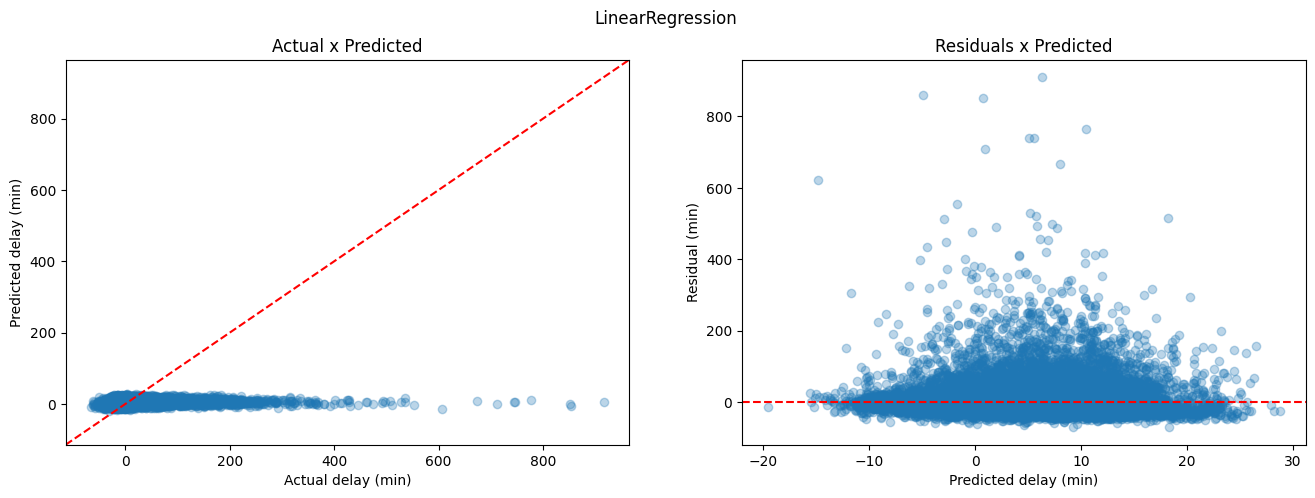



Metrics:
MAE:  21.3123
RMSE: 39.8816


Feature Importance:
                                 feature   importance
19                           freq__ROUTE  1918.702903
28         minmax_scaler__SCHEDULED_TIME   158.001630
27               minmax_scaler__DISTANCE   133.097343
17                freq__DESTINATION_CITY    46.729319
15                    freq__ORIGIN_STATE    18.543851
25               ord_minmax_scaler__HOUR    17.408873
18               freq__DESTINATION_STATE    13.154586
7                        ohe__AIRLINE_NK     9.146681
4                        ohe__AIRLINE_F9     8.485730
30    minmax_scaler__ARRIVAL_ACC_MINUTES     7.878319
29  minmax_scaler__DEPARTURE_ACC_MINUTES     5.703285
14                     freq__ORIGIN_CITY     5.332153
2                        ohe__AIRLINE_DL     4.473799
38    remainder__HOLIDAY_EVE_DESTINATION     4.194369
26    ord_minmax_scaler__FLIGHT_SEQUENCE     3.622859
32          std_scaler__ORIGIN_LONGITUDE     3.202516
11                   

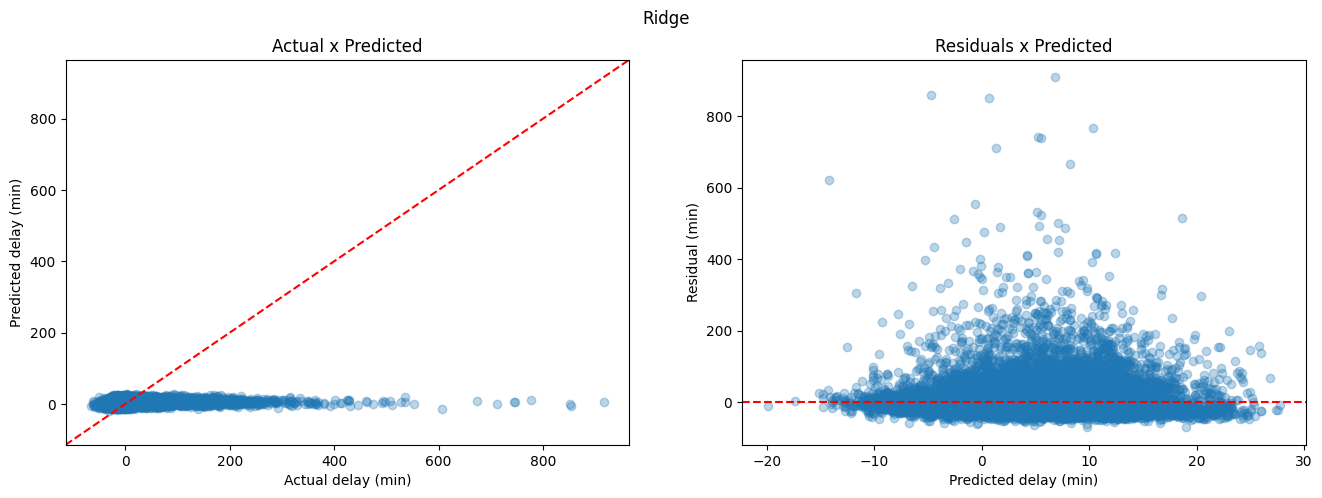



Metrics:
MAE:  21.3266
RMSE: 39.8832


Feature Importance:
                                 feature  importance
28         minmax_scaler__SCHEDULED_TIME  146.147962
19                           freq__ROUTE  122.614150
27               minmax_scaler__DISTANCE  121.143588
17                freq__DESTINATION_CITY   49.067576
15                    freq__ORIGIN_STATE   19.603539
25               ord_minmax_scaler__HOUR   18.393855
13                  freq__ORIGIN_AIRPORT   17.641791
16             freq__DESTINATION_AIRPORT   15.810792
18               freq__DESTINATION_STATE   14.260333
7                        ohe__AIRLINE_NK    9.201924
14                     freq__ORIGIN_CITY    8.581126
4                        ohe__AIRLINE_F9    8.503196
30    minmax_scaler__ARRIVAL_ACC_MINUTES    7.757068
29  minmax_scaler__DEPARTURE_ACC_MINUTES    6.524591
2                        ohe__AIRLINE_DL    4.637770
38    remainder__HOLIDAY_EVE_DESTINATION    4.220600
26    ord_minmax_scaler__FLIGHT_SEQUEN

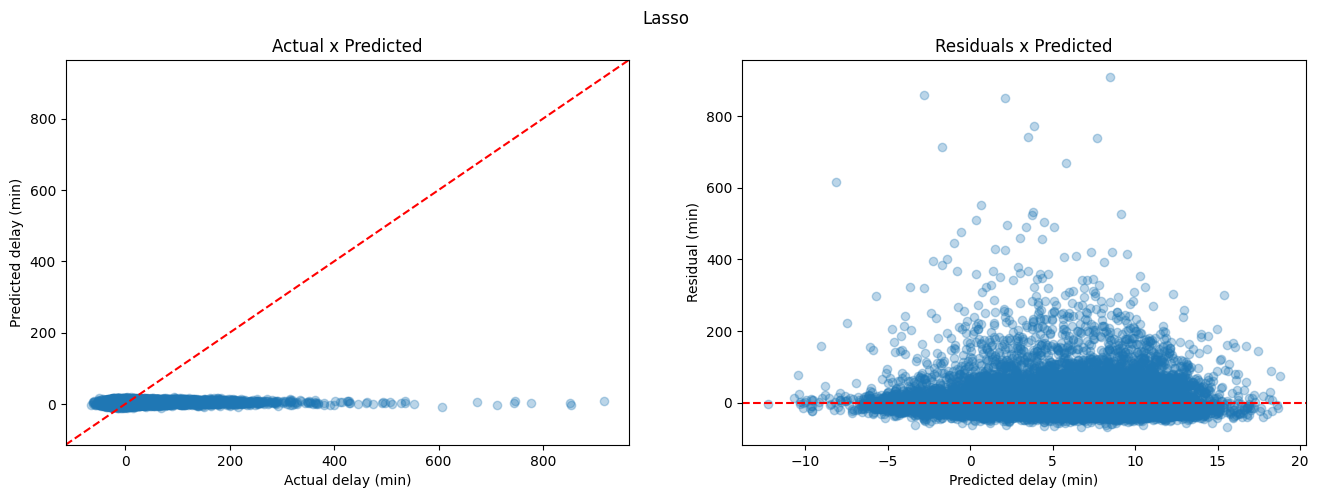



Metrics:
MAE:  21.3535
RMSE: 39.9724


Feature Importance:
                                 feature  importance
25               ord_minmax_scaler__HOUR   13.295498
30    minmax_scaler__ARRIVAL_ACC_MINUTES    5.372797
7                        ohe__AIRLINE_NK    4.900033
2                        ohe__AIRLINE_DL    4.422023
21          ord__SCHEDULED_TIME_CATEGORY    2.821395
4                        ohe__AIRLINE_F9    2.289225
22              ord_minmax_scaler__MONTH    2.050126
24        ord_minmax_scaler__DAY_OF_WEEK    1.232391
0                        ohe__AIRLINE_AS    0.789906
34     std_scaler__DESTINATION_LONGITUDE    0.701118
3                        ohe__AIRLINE_EV    0.435399
10                       ohe__AIRLINE_US    0.069225
32          std_scaler__ORIGIN_LONGITUDE    0.058352
12                       ohe__AIRLINE_WN    0.009279
1                        ohe__AIRLINE_B6    0.000000
6                        ohe__AIRLINE_MQ    0.000000
5                        ohe__AIRLINE_

In [17]:
for model_name, pipeline in reg_pipelines.items():
    print(f"GridSearch - {model_name}")
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=reg_param_grids[model_name],
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    grid_search.fit(X_reg_train, y_reg_train)

    print("CV Results:")
    cv_split_score_cols = ["split0_test_score", "split1_test_score", "split2_test_score", "split3_test_score", "split4_test_score"]
    df_cv_results = pd.DataFrame(grid_search.cv_results_)[["params"] + cv_split_score_cols + ["mean_test_score"]]
    df_cv_results = pd.concat([
        pd.json_normalize(df_cv_results["params"]),
        np.sqrt(-df_cv_results[cv_split_score_cols + ["mean_test_score"]]),
        np.sqrt(-df_cv_results[cv_split_score_cols]).std(axis=1).rename("std_rmse"),
    ], axis=1)
    df_cv_results.rename(columns=lambda c: c.replace("test_score", "rmse") if "test_score" in c else c, inplace=True)
    print(df_cv_results)
    print("\n")

    print(f"Best Parameters: {grid_search.best_params_}")
    print("\n")

    best_model = grid_search.best_estimator_
    y_reg_pred = best_model.predict(X_reg_test)

    print("Regression Plots:")
    regression_plots(y_reg_test, y_reg_pred, model_name)
    print("\n")

    print("Metrics:")
    print(f"MAE:  {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}")
    print("\n")

    print("Feature Importance:")
    df_feature_importance = pd.DataFrame({
        "feature": best_model.named_steps["preprocessor"].get_feature_names_out(),
        "importance": np.abs(best_model.named_steps["regressor"].coef_).flatten(),
    }).sort_values("importance", ascending=False)
    print(df_feature_importance)
    print("\n")